# Basic demonstration of fUSi analysis

This notebook is designed to demonstrate the process of loading functional ultrasound imaging (fUSi) data and associated behavioral metadata. It outlines the steps to preprocess the data, generate statistical parametric maps, and extract time series data from regions of interest (ROIs).

Note that this notebook is built around the dataset collected with UCLA after applying SSEPs and is only running a single run at a time. We'll need fancier approaches to integrate multiple runs, or run more interesting comparisons between multiple conditions


Ultimetly we get something like the figure below, which shows us the stastically significant regions of the fUSi data as well as the corresponding time series data for each ROI.
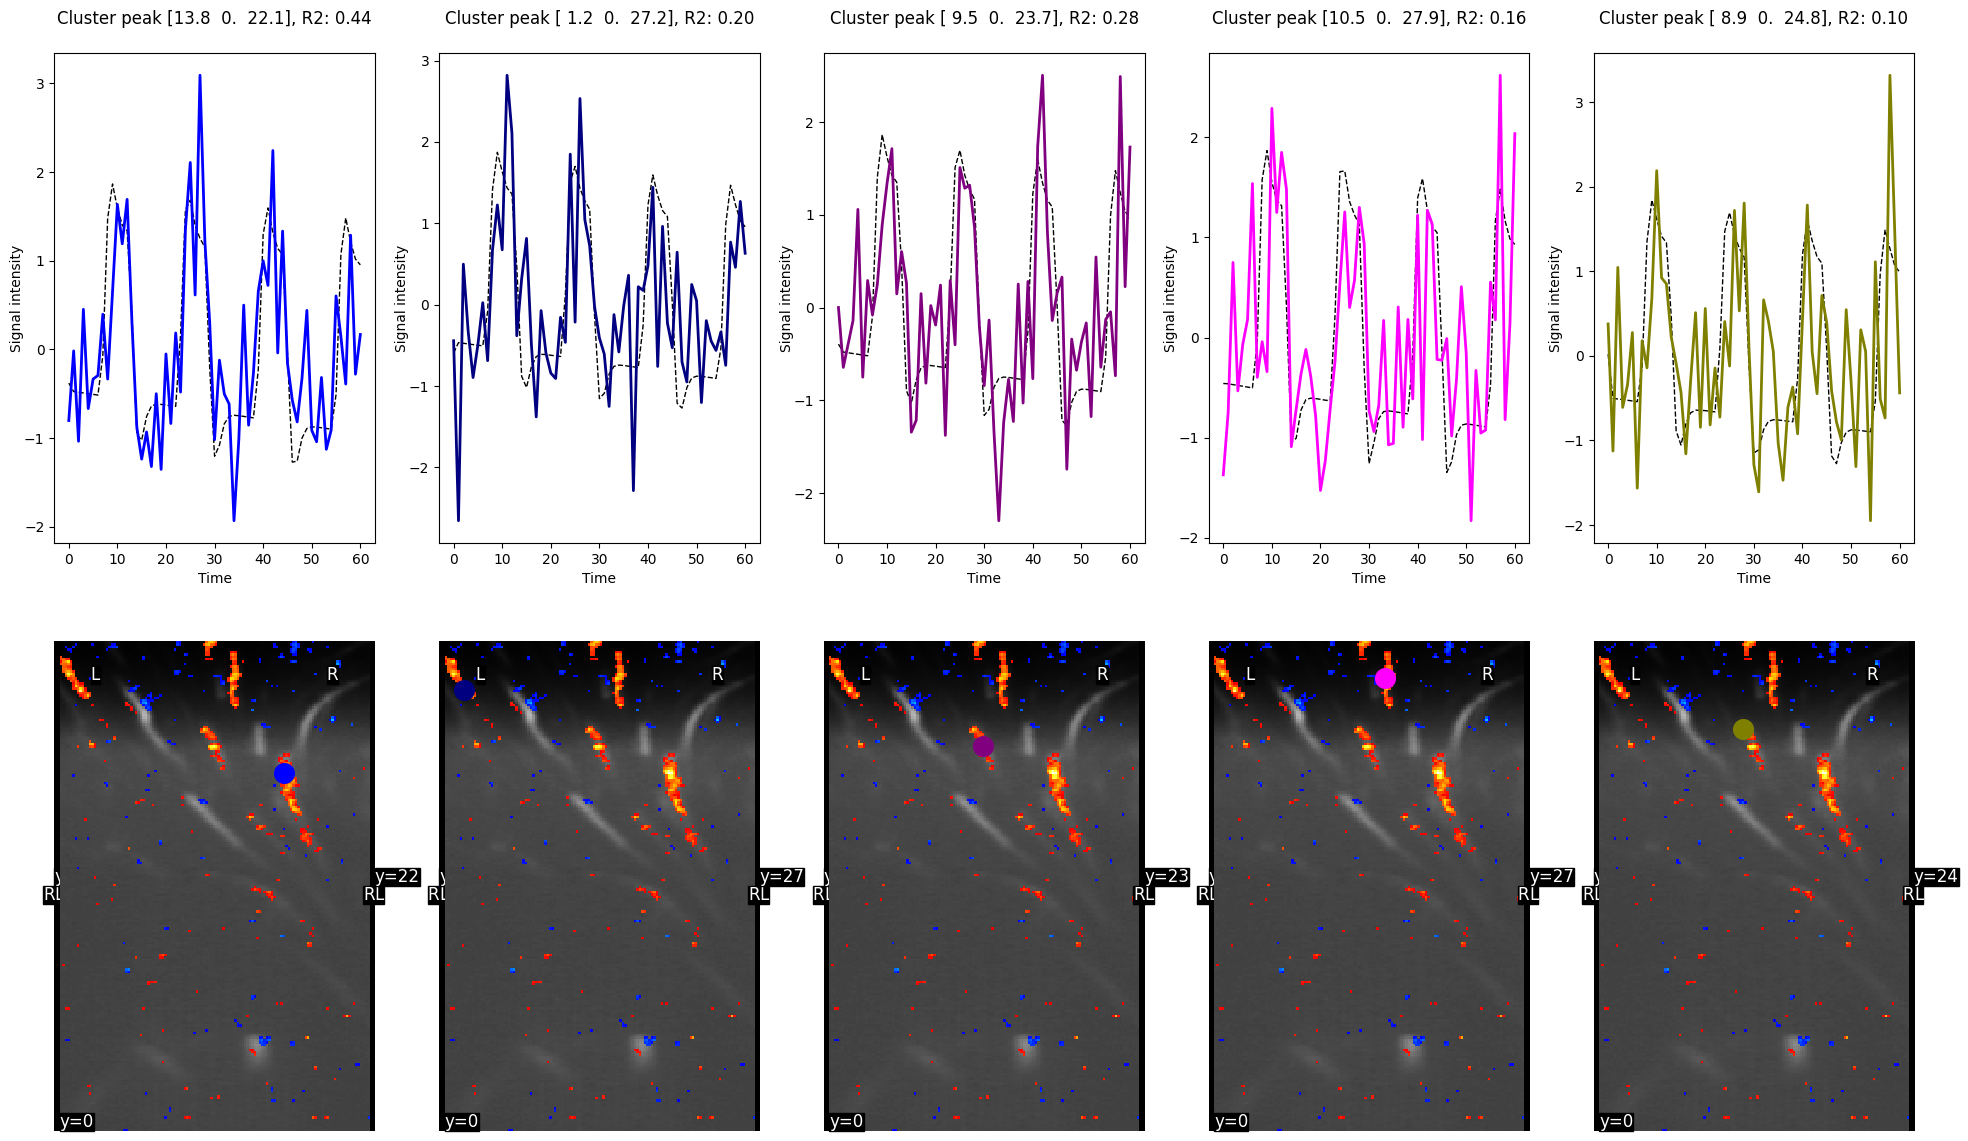



Some human results that we can compare against:

Arthurs et al. What aspect of the fMRI BOLD signal best reflects the underlying electrophysiology in human somatosensory cortex?
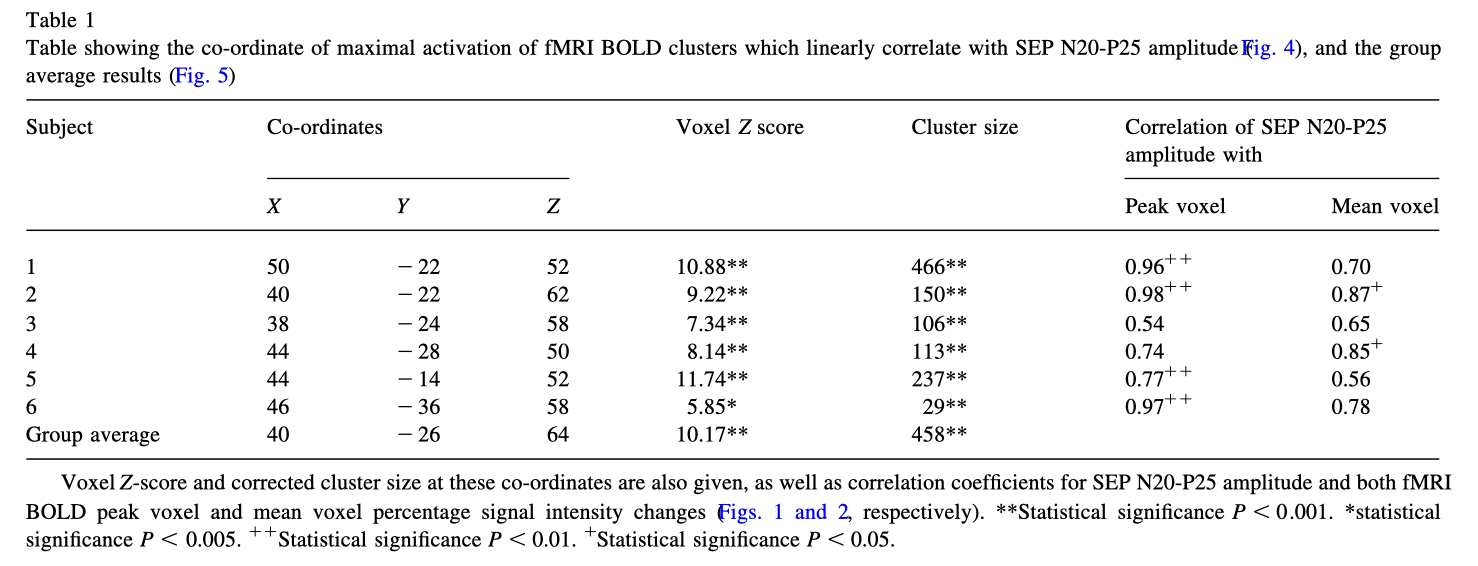

Storti et al. Neurophysiological and BOLD signal uncoupling of giant somatosensory evoked potentials in progressive myoclonic epilepsy: a case-series study

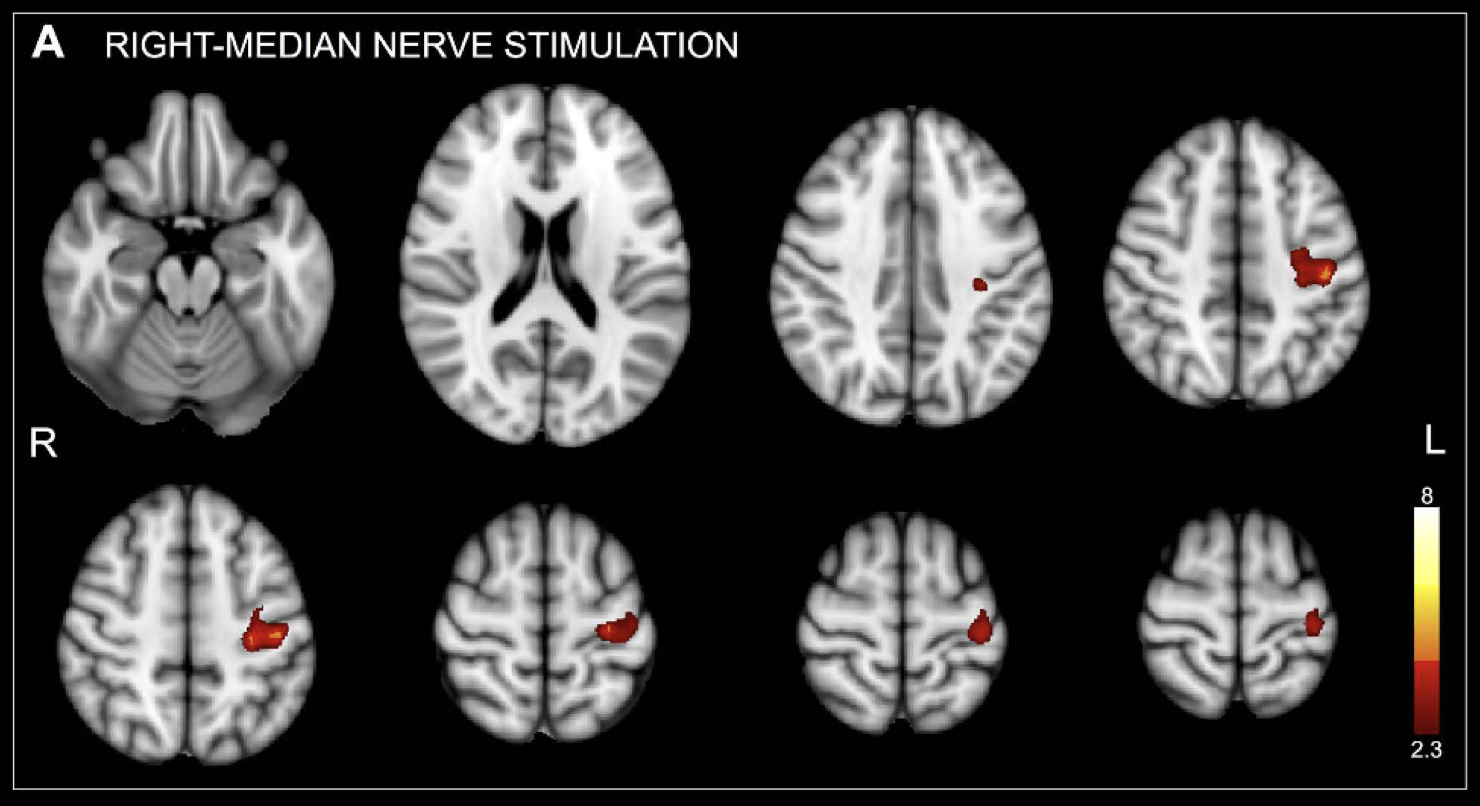

In [47]:
%load_ext autoreload
%autoreload 2
from nilearn import plotting


import nilearn as nl
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import os
import pandas as pd
import re

from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

from ucla_fusi_utils import DirectoryManager
import ucla_fusi_utils as utils


from pathlib import Path
from datetime import datetime, timedelta

from anise.io.load_matlab_dataset import load_data, load_selected_data



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
# define arguements to specify the data to be processed
# base_path=Path('/Users/taflalo/Data/UCLA/2024-04-19/UCLA-003/ses-2024-04-19/run-01')
base_path=Path('/Volumes/192.168.1.169/UCLA_collaboration/2024-04-19/UCLA-003/ses-2024-04-19/run-01')
sequence = 'seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops'
# sequence = 'seq-RF_4000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops'
# sequence = 'seq-RF_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops'

# base_path=Path('/Users/taflalo/Data/UCLA/2024-04-19/UCLA-003/ses-2024-04-19/run-04')
# sequence = 'seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops'
# sequence = 'seq-RF_4000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops'
# sequence = 'seq-RF_4000000Hz_5a_3c_2rp_10Dmin_40Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops'


event_time_offset = 3  # Offset in seconds to apply to stimulus onsets. This can be used to correct for differences between when the instruction is given and when the stimulus is presented.
apply_image_registration=False # If true, we will register the fUSi data to the first frame. If false, we will not register the fUSi data.
time_zone_offset=7

smoothing_fwhm=.5 # spatial smoothing in mm to apply to the data before computing GLM

dm = DirectoryManager(base_path, sequence)
dm.list_acquisition_directories()
dm.print_paths()

/Volumes/192.168.1.169/UCLA_collaboration/2024-04-19/UCLA-003/ses-2024-04-19/run-01/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops/fUSI
Directories in acquisitions path:
    seq-RF_4000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops
    seq-RF_4000000Hz_5a_3c_2rp_45Dmin_70Dmax_6el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops
    seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops
    seq-RF_5000000Hz_5a_3c_2rp_45Dmin_70Dmax_6el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops
List of all directories in acquisitions path:
    log_file_path: /Volumes/192.168.1.169/UCLA_collaboration/2024-04-19/UCLA-003/ses-2024-04-19/run-01/logs/task_1.log
    sequence_data_path: /Volumes/192.168.1.169/UCLA_collaboration/2024-04-19/UCLA-003/ses-2024-04-19/run-01/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops
    raw_data_path: /Vo

In [49]:
# If beamforming and power doppler have not been performed, perform them using the following commands in your terminal (make sure mangrove is activated!)
# Command to execute the mangrove raw data to beamformed conversion
beamform_command =  f'python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="{dm.sequence_data_path}"'
power_doppler_command =  f'python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="{dm.sequence_data_path}"'

print(beamform_command)
print(power_doppler_command)

python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="/Volumes/192.168.1.169/UCLA_collaboration/2024-04-19/UCLA-003/ses-2024-04-19/run-01/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops"
python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="/Volumes/192.168.1.169/UCLA_collaboration/2024-04-19/UCLA-003/ses-2024-04-19/run-01/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops"


In [50]:
# Create the events data structure to create a design matrix
fusi_info=utils.load_fUSi_info(dm.power_doppler_path)
task_info=utils.process_task_log(dm.log_file_path,fusi_info,timeoffset=time_zone_offset)
events=utils.calculate_stimulus_events(task_info)

# Add a specified offset to the event times
events['onset'] += event_time_offset

Convert the pandas data structure into something importable to nilearn


In [51]:


# get fusi data
# frame_indices specifies with power doppler frames to read in. This would be a list e.g. [0,1,2,3...] or just use -1 to specify all
frame_indices = -1  # Specify the frame indices you want to import
fusi_data = utils.get_fusi_frames(dm.power_doppler_path, fusi_info, frame_indices)
fusi_data.shape

plot_transformations=True
if apply_image_registration:
    fusi_data_3d = fusi_data[:, 0, :, :]  # Keep only the first index of the second dimension
    # output_path=str(dm.fUSI_data_path/f"AcquisitionMovie_orig_{sequence}.png") 
    # video = utils.create_video_from_3d_data(fusi_data,output_path=output_path) # this was bugging, need to debug
    # fusi_data_3d=fusi_data_3d-np.min(fusi_data_3d)
    # fusi_data_3d=fusi_data_3d/np.max(fusi_data_3d) *256
    fusi_data_3d_reg,transformations=utils.register_image_stack(fusi_data_3d)
    # fusi_data_3d_reg,transformations=utils.register_ants(fusi_data_3d)
    # Reintroduce the second dimension and tile the data
    fusi_data_3d_reg_expanded = np.expand_dims(fusi_data_3d_reg, axis=1)  # Add a singleton dimension at axis 1
    # output_path=str(dm.fUSI_data_path/f"AcquisitionMovie_reg_{sequence}.png")
    # video = utils.create_video_from_3d_data(fusi_data,output_path=output_path)
    # display(video)
    fusi_data = np.tile(fusi_data_3d_reg_expanded, (1, 2, 1, 1))
    if plot_transformations:
        plt.figure(figsize=(10, 4))
        plt.plot(transformations[0, :], label='Translation X')
        plt.plot(transformations[1, :], label='Translation Y')
        plt.plot(transformations[2, :]*180/np.pi, label='Rotation Angle')

        
        plt.title('Transformation Parameters Over Frames')
        plt.xlabel('Frame Index')
        plt.ylabel('Transformation Value')
        plt.legend()
        plt.grid(True)
        plt.show()



In [52]:

hrf_model = "glover"
if apply_image_registration:
    design_matrix = make_first_level_design_matrix(
        fusi_info['Experiment Time'] ,
        events,
        drift_model="polynomial",
        drift_order=1,
        add_regs=transformations.transpose(),
        add_reg_names=["tx","ty","rot"],
        hrf_model=hrf_model,
    )
else:
    design_matrix = make_first_level_design_matrix(
        fusi_info['Experiment Time'] ,
        events,
        drift_model="polynomial",
        drift_order=1,
        hrf_model=hrf_model,
    )

fig = plt.figure()
plot_design_matrix(design_matrix)
fig.show()

print(fusi_info)
print(task_info)
print(events)

/Users/taflalo/miniconda3/envs/Anise/lib/python3.9/site-packages/nilearn/glm/first_level/hemodynamic_models.py:68: RuntimeWarning:

divide by zero encountered in scalar divide

/Users/taflalo/miniconda3/envs/Anise/lib/python3.9/site-packages/nilearn/glm/first_level/hemodynamic_models.py:68: RuntimeWarning:

invalid value encountered in cast



ValueError: array is too big; `arr.size * arr.dtype.itemsize` is larger than the maximum possible size.

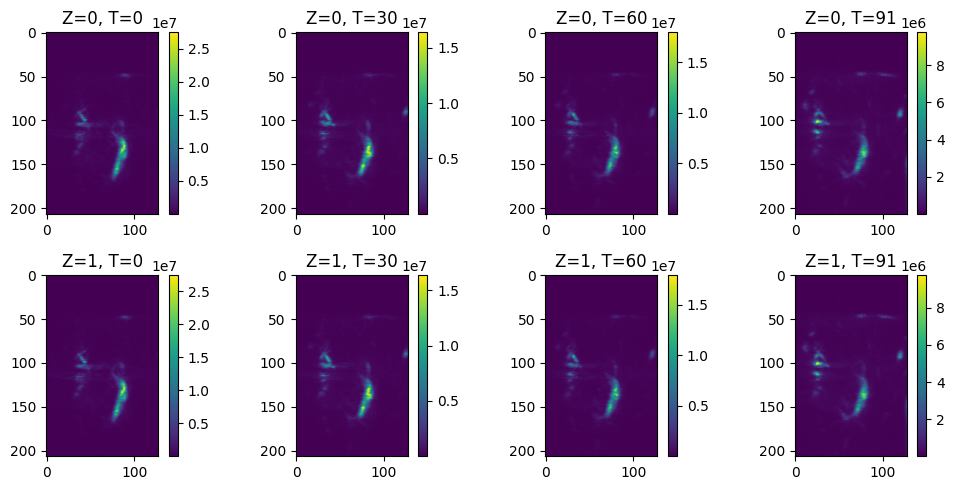

In [ ]:
# Plot the data, make sure nothing crazy is happening, in particular, as I am mocking a 3D scan to play nice with nilearn, we need to make sure the data is in the right shape and the info across the second dimension is simply a copy
import matplotlib.pyplot as plt
# visualize to ensure we are getting what we think we should be getting!

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(10, 5))  # 2 rows for Z dimension, 4 columns for T dimension
for z_dim in range(2):  # Loop over the Z dimension (1 dimension)
    for t_index, t_dim in enumerate(np.linspace(0, fusi_data.shape[3] - 1, 4, dtype=int)):  # Sample 4 equally spaced indices along the T dimension
        ax = axs[z_dim, t_index]
        img_plot = ax.imshow(np.flip(fusi_data[:, z_dim, :, t_dim].transpose(), axis=0), aspect='equal')
        ax.set_title(f'Z={z_dim}, T={t_dim}')
        plt.colorbar(img_plot, ax=ax)

plt.tight_layout()
plt.show()

Data shape is (128, 2, 207)


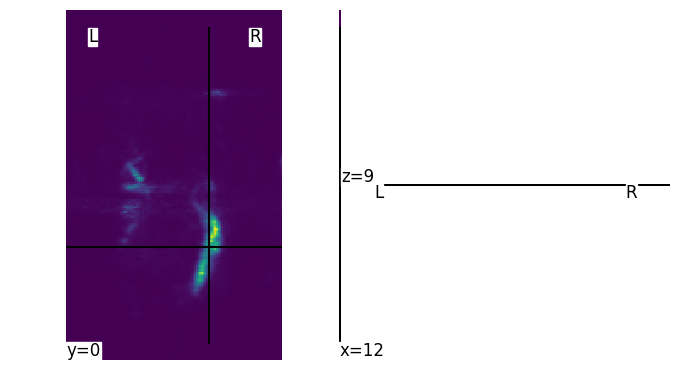

In [ ]:
# quick sanity check that conversion to nifti / save/load are working.
from nilearn import image
import nibabel as nib

affine=np.diag([.15,.15,.15,0])
pd=np.array(fusi_data[:,:,:,0])
nifti_img = nib.Nifti1Image(pd, affine)
nifti_img.to_filename(dm.fUSI_data_path/"fUSi_data.nii.gz")
tmp=image.load_img(dm.fUSI_data_path/"fUSi_data.nii.gz")
print(f'Data shape is {tmp.shape}')
plotting.plot_img(tmp)

In [ ]:
from nilearn.signal import butterworth


affine=np.diag([.15,.15,.15,0])
# pd=np.array(fusi_data)
def boxcar_smooth(data, window_size):
    if window_size>0:
        smoothed_data = np.copy(data)
        for t in range(data.shape[3]):
            start_index = max(0, t - window_size // 2)
            end_index = min(data.shape[3], t + window_size // 2 + 1)
            smoothed_data[:, :, :, t] = np.mean(data[:, :, :, start_index:end_index], axis=3)
    else:
        smoothed_data=data
    return smoothed_data

window_size = 0  # Number of time points for smoothing
pd = boxcar_smooth(fusi_data, window_size)
nifti_img = nib.Nifti1Image(pd, affine)
nifti_img.to_filename(dm.fUSI_data_path/"fUSi_data.nii.gz")
nifti_data=image.load_img(dm.fUSI_data_path/"fUSi_data.nii.gz")
nifti_data.shape

(128, 2, 207, 92)

In [ ]:
contrast_matrix = np.eye(design_matrix.shape[1])
basic_contrasts = {
    column: contrast_matrix[i]
    for i, column in enumerate(design_matrix.columns)
}
basic_contrasts

{'Stimulus on': array([1., 0., 0.]),
 'drift_1': array([0., 1., 0.]),
 'constant': array([0., 0., 1.])}

In [ ]:
from nilearn.glm.first_level import FirstLevelModel

print("Fitting a GLM")
fmri_glm = FirstLevelModel(minimize_memory=False,mask_img=False,smoothing_fwhm=smoothing_fwhm,standardize=True)
fmri_glm = fmri_glm.fit(nifti_data, design_matrices=design_matrix)

Fitting a GLM


Computing contrasts
	contrast id: Stimulus on


/Users/taflalo/miniconda3/envs/Anise/lib/python3.9/site-packages/nilearn/plotting/find_cuts.py:315: UserWarning:

Too many cuts requested for the data: n_cuts=7, data size=2.



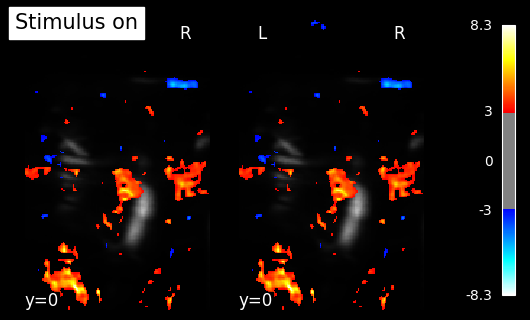

	contrast id: drift_1


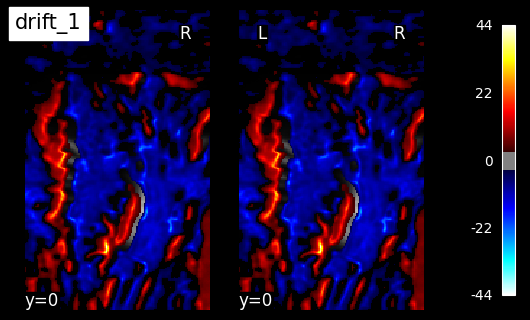

	contrast id: constant


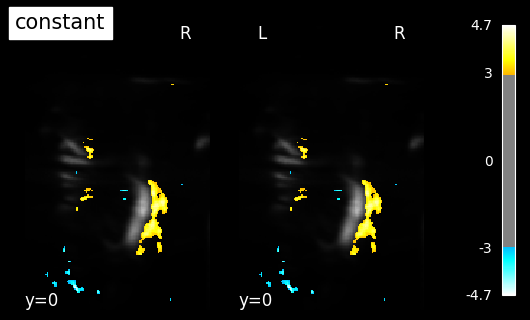

In [ ]:
from nilearn import plotting
from nilearn.image import concat_imgs, mean_img, resample_img

print("Computing contrasts")

mean_image = mean_img(nifti_data)
# Iterate on contrasts
for contrast_id, contrast_val in basic_contrasts.items():
    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat") # 
    # plot the contrasts as soon as they're generated
    # the display is overlaid on the mean fMRI image
    # a threshold of 3.0 is used, more sophisticated choices are possible
    plotting.plot_stat_map(
        z_map,
        bg_img=mean_image,
        threshold=3,        

        display_mode="y",        
        black_bg=True,        
        title=contrast_id,
    )
    plotting.show()

# Plot time series for ROI response and stimulus regressor

Identify ROIs using an automated clustering approach. Extract the time series for each ROI. Plot the time series and corresponding locations.



In [ ]:
from nilearn.maskers import NiftiSpheresMasker
from nilearn.reporting import get_clusters_table

num_locations=4

# Find ROIs by identifying the locations that show a significant response to the stimulus
mean_image = mean_img(nifti_data)
z_map = fmri_glm.compute_contrast(basic_contrasts['Stimulus on'], output_type="stat")
# z_map = fmri_glm.compute_contrast(basic_contrasts['drift_1'], output_type="stat")
table = get_clusters_table(z_map, stat_threshold=3.1, cluster_threshold=20)
table.set_index("Cluster ID", drop=True)
table.head()

# get the 6 largest clusters' max x, y, and z coordinates
coords = table.loc[range(0, num_locations), ["X", "Y", "Z"]].values
coords = np.vstack([coords, [10.45000061,  0.        , 18.40000045]])

# Now use the ROIs to extract the time series 
masker = NiftiSpheresMasker(coords)
standardize="psc" # zscore psc
masker = NiftiSpheresMasker(
    coords,
    radius=.5,
    detrend=True,
    standardize=standardize, # zscore psc
    # low_pass=0.1,
    # high_pass=0.01,
    t_r=3.5,
    # memory="nilearn_cache",
    memory_level=1,
    verbose=0,
)

real_timeseries = masker.fit_transform(nifti_data)
# predicted_timeseries = masker.fit_transform(fmri_glm.predicted[0])
predicted_timeseries = np.tile(design_matrix['Stimulus on'].values, (real_timeseries.shape[1], 1)).T


In [ ]:
from sklearn.metrics import r2_score

# Calculate the R-squared value for each ROI
r_squared_values = []
for i in range(real_timeseries.shape[1]):
    r_squared = r2_score(real_timeseries[:, i], predicted_timeseries[:, i])
    r_squared_values.append(r_squared)

# Display the R-squared values
print("R-squared values for each ROI:")
for idx, r2 in enumerate(r_squared_values):
    print(f"ROI {idx + 1}: {r2:.3f}")


R-squared values for each ROI:
ROI 1: 0.114
ROI 2: 0.050
ROI 3: 0.078
ROI 4: 0.050
ROI 5: 0.005


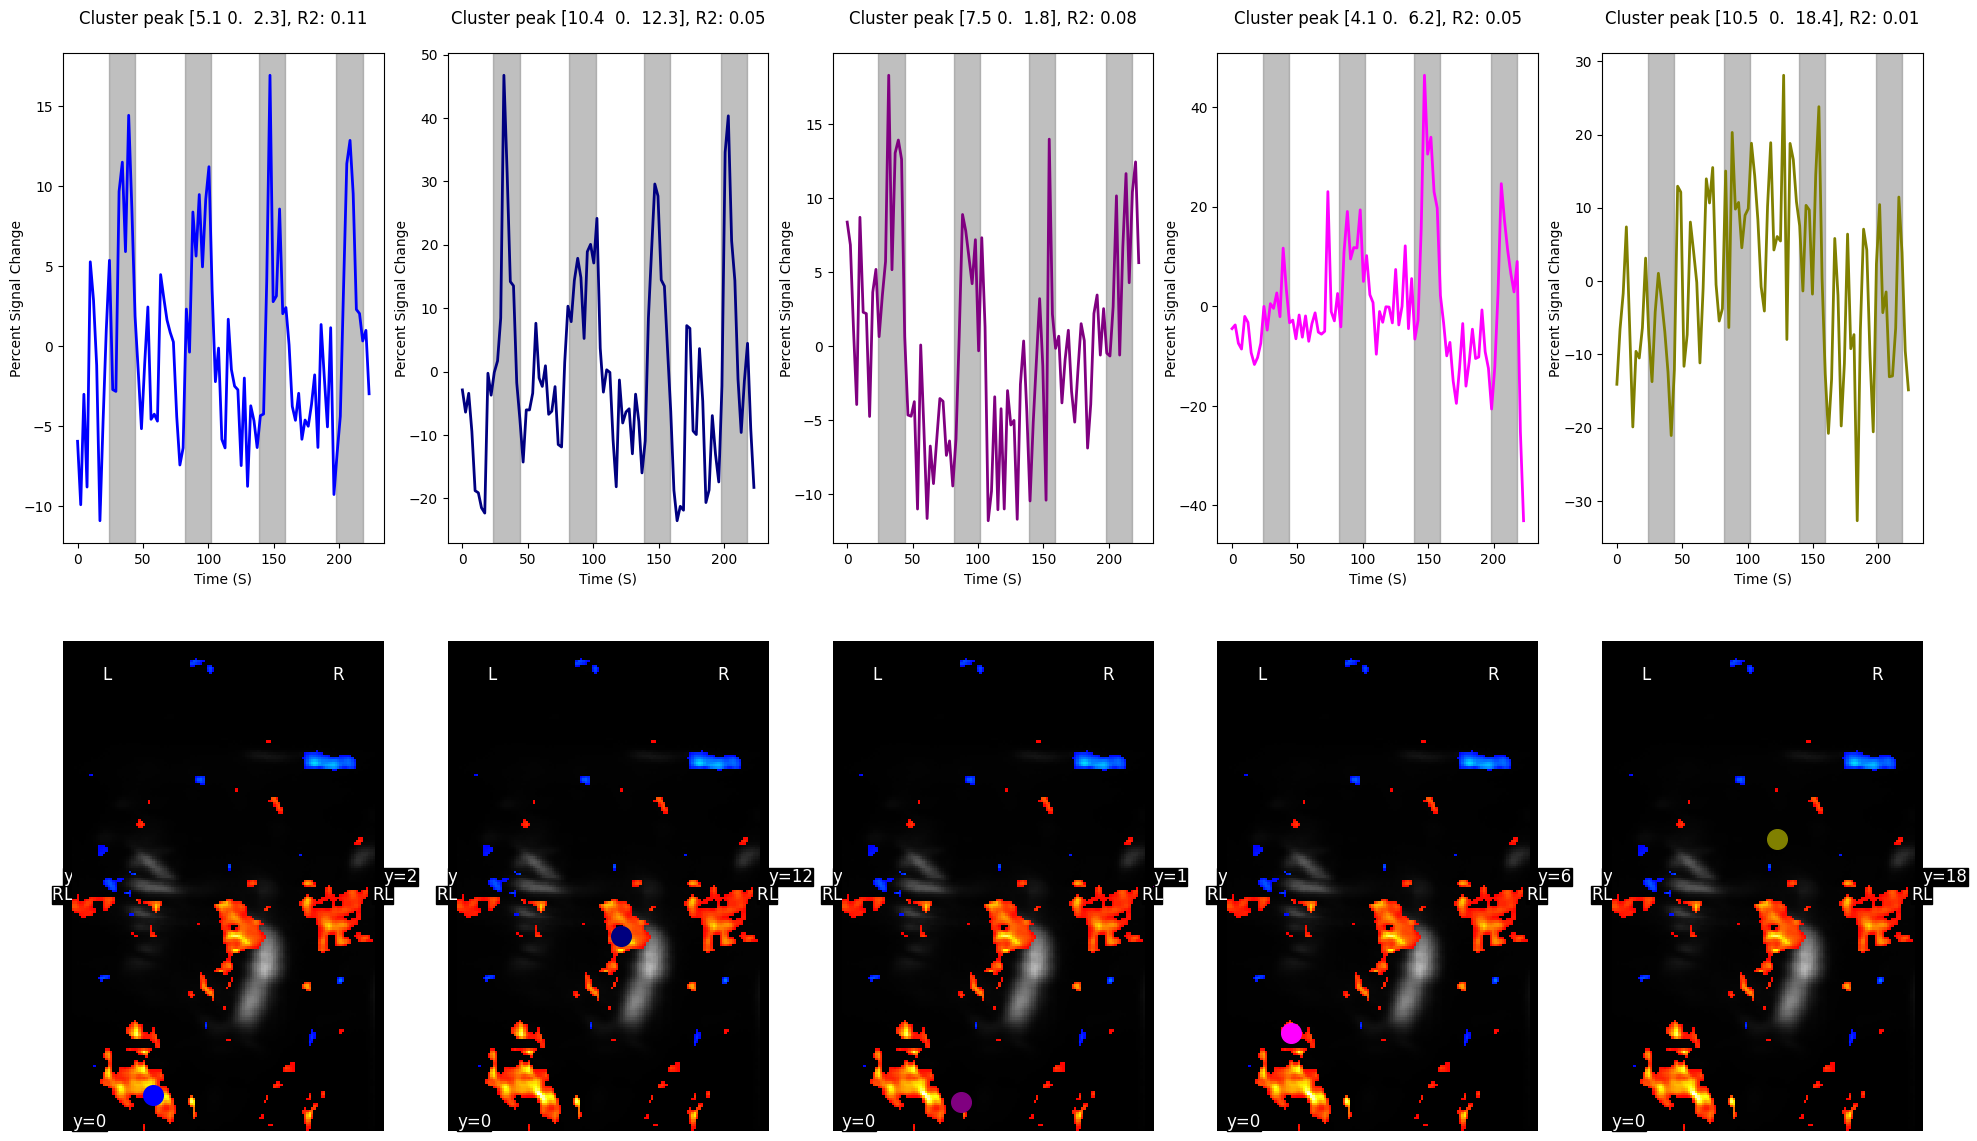

In [ ]:
# And finaly, plot the time series for each ROI and the corresponding location of each ROI
# colors for each of the clusters
colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
# plot the time series and corresponding locations
fig1, axs1 = plt.subplots(2, 5)
for i in range(5):
    # plotting time series
    axs1[0, i].set_title(f"Cluster peak {coords[i].round(1)}, R2: {r_squared_values[i]:.2f}\n")
    if masker.standardize != "psc":
        axs1[0, i].plot(fusi_info['Experiment Time'], predicted_timeseries[:, i], c="k", ls="--", lw=1)
    # axs1[0, i].plot(fusi_info['Experiment Time'], predicted_timeseries[:, i], c="k", ls="--", lw=1)
    # axs1[0, i].plot(fusi_info['Experiment Time'], design_matrix['Stimulus on'], c="k", ls="--", lw=1)
    axs1[0, i].plot(fusi_info['Experiment Time'], real_timeseries[:, i], c=colors[i], lw=2)
    axs1[0, i].set_xlabel("Time (S)")

    if masker.standardize == "psc":
        axs1[0, i].set_ylabel('Percent Signal Change', labelpad=0)
    else:
        axs1[0, i].set_ylabel("Signal intensity", labelpad=0)

    # plotting image below the time series
    # Highlight regions of time described by the onsets and durations in events
    # Assuming 'events' is a DataFrame with columns 'onset' and 'duration' for stimulus events
    for onset, duration in zip(events['onset'], events['duration']):
        axs1[0, i].axvspan(onset+event_time_offset, onset + duration+event_time_offset, color='gray', alpha=0.5)
    
    roi_img = plotting.plot_stat_map(
        z_map,
        cut_coords=coords[i],
        threshold=3,
        figure=fig1,
        axes=axs1[1, i],
        display_mode="y",
        colorbar=False,
        bg_img=mean_image,
    )
    
    roi_img.add_markers([coords[i]], colors[i], 200)
fig1.set_size_inches(24, 14)

# fig1.savefig(dm.fUSI_data_path/f"ROI_time_series_{sequence}.png")



In [ ]:
real_timeseries[:, i] 

array([-14.06827861,  -6.54437573,  -1.66175234,   7.39741805,
        -6.00002414, -19.88832823,  -9.57738904, -10.48344656,
        -6.37225234,   3.1415989 ,  -7.31006462, -13.71232122,
        -4.20471409,   1.06758863,  -2.66768565,  -6.89313491,
       -12.40451961, -21.06253176, -12.06130623,  12.94665504,
        12.14655874, -11.61841516,  -7.3066079 ,   8.05625552,
         4.06416704,  -0.17154175, -11.16056046,  -0.94534899,
        13.95530959,  10.66238108,  15.49606399,  -0.46629516,
        -5.44671256,  -3.73833692,  15.016588  ,  -6.32122193,
        20.28019987,   9.82548546,  10.73222698,   4.55121674,
         8.98440162,   9.88225701,  18.80901804,  14.351417  ,
         8.38563803,  -0.76498167,  -4.08021235,  10.19273622,
        18.8809542 ,   4.24764541,   6.0866166 ,   5.47662468,
        28.07877427,  -7.96140385,  18.78471154,  16.58002271,
        10.81160204,   7.5321874 ,  -1.3447979 ,  10.33411553,
         9.70304001,  -1.77023898,  14.42783813,  23.79

# Ignore below

Below is some code blocks that I was playing with to get the ROI response and stimulus regressor plotted.



In [ ]:
# z_map = fmri_glm.compute_contrast(basic_contrasts['Stimulus on'], output_type="stat")
# view = plotting.view_img(z_map, threshold=3,bg_img=mean_image,cut_coords=[7,0,8.6])
# view